# Does a Neutral Reminder Increase New Chat Sessions in LLM Interfaces?

**Authors:** Abigail Kreutz, Jana Quan, Killian Carter, Luan Ye

**Abstract.** Safety and performance behavior in large language models can degrade as a conversation accumulates turns. Starting a new chat may reduce exposure to this long-context risk, but restarting is easy to overlook while working. We ran a between-subjects randomized controlled trial through a Chrome extension that instruments five LLM web interfaces. Treatment participants received a neutral reminder to create new chats often; control participants received the same platform disclaimer without that reminder. Of 34 randomized users, 12 remained in the analysis sample after an activity-based exclusion, 4 in control and 8 in treatment. Treatment participants initiated 3.38 more new chats on average than control participants, but randomization inference does not reject the sharp null of no effect for any participant (p = 0.298), and realized power at the observed outcome variance is roughly 0.07. The estimated effect on active time is driven by which participants remained in each arm rather than by a plausible treatment effect. The study is therefore inconclusive on both hypotheses, and its main contribution is a reusable design, instrumentation, and analysis plan for a better-powered replication.

In [ ]:
# Colab's R runtime preinstalls data.table, jsonlite, and ggplot2.
# sandwich and lmtest usually need installing
needed <- c('sandwich', 'lmtest')
missing <- needed[!needed %in% rownames(installed.packages())]
if (length(missing) > 0) install.packages(missing)

In [ ]:
# hide
library(data.table)
library(jsonlite)

library(sandwich)
library(lmtest)

library(ggplot2)

In [ ]:
# hide
drive_file_id <- '1-A-GGVKRSUQ9YtknaCNs3c_eLGSSFtmk'
force_refresh <- FALSE   # set TRUE if a new version was uploaded mid-session

data_dir  <- '/content/data'
data_file <- '/content/data/ai-experiment-data-241-default-rtdb-export-FINAL.json'

dir.create(data_dir, showWarnings = FALSE, recursive = TRUE)

options(HTTPUserAgent = 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0 Safari/537.36')

if (force_refresh || !file.exists(data_file)) {
  data_url <- sprintf('https://drive.usercontent.google.com/download?id=%s&export=download&confirm=t', drive_file_id)
  download.file(data_url, destfile = data_file, mode = 'wb', quiet = TRUE)
}

# Drive returns an HTML page instead of the file when sharing is misconfigured
if (!substr(readChar(data_file, 1), 1, 1) %in% c('{', '[')) {
  stop('Downloaded file is not JSON. Check the file ID and that sharing is set to "Anyone with the link".')
}

cat(sprintf('data file : %s\nsize      : %.1f KB\nretrieved : %s\n',
            data_file, file.size(data_file) / 1024,
            format(file.mtime(data_file), '%Y-%m-%d %H:%M:%S %Z')))

set.seed(241)

# Experiment start time from the Firebase configuration history; re-verify if the export is ever refreshed
experiment_start <- as.POSIXct('2026-07-27 12:00:00', tz = 'UTC')

# Installs that never accumulated more than this much active time are treated as non-participants rather than as observations and/or attrition
min_total_seconds <- 10


data file : /content/data/ai-experiment-data-241-default-rtdb-export-FINAL.json
size      : 128.6 KB
retrieved : 2026-08-11 05:08:39 UTC


# Introduction

Recent work suggests that safety- and performance-relevant behavior can worsen over long, multi-turn LLM conversations. Laban et al. (2025) find that leading models perform worse on average in multi-turn than single-turn settings. Zhou et al. (2024) show that a request refused when asked directly can evade the same safeguard when it is decomposed across turns. Yu et al. (2025) observe falling refusal rates as retrieval context grows, and Shukla et al. (2025) find more critical vulnerabilities after repeated code-refinement rounds. Together, these studies suggest that an accumulating conversational context window can create safety and reliability risks. Starting a new chat ends the current conversation context. It is a low-cost user action, but it may not be top of mind while someone is focused on a task and wants to preserve the context already visible in the chat. This study does not test whether restarting improves a model's safety. It tests whether a neutral reminder changes restart behavior.

Our research question is: **does a neutral reminder shown when a user loads an instrumented LLM platform increase new-chat creation without reducing overall active time on the platform?**

We use a neutral message rather than an informational safety warning so that the intervention does not try to change participants' beliefs about AI safety. If the message changes behavior, the proposed mechanism is salience: the reminder makes restarting noticeable at a moment when a user might otherwise continue in the current chat. This design cannot prove that mechanism, but the neutral framing makes persuasion a less likely explanation than it would be for a safety-warning message.

**H1.** Participants who receive the reminder initiate more new chat sessions than participants who do not. This is the primary confirmatory hypothesis. If salience is the main barrier, making the option visible should increase restart behavior.

**H2.** Participants who receive the reminder do not spend less total time on these platforms than participants who do not. The reminder asks users to restart rather than to stop. We will assess H2 using the confidence interval for the effect on active time, not a non-significant result alone.

We did not pre-specify a practically meaningful decline in active minutes before data collection ended. Because that threshold was never locked, we do not make a strong no-harm claim from the final interval. Section 4.5 reports the interval and describes what it can and cannot rule out.

**H3 (exploratory).** The effect in H1 may be larger among participants who use these tools more heavily, because they have more chances to encounter the reminder. We do not observe pre-treatment use, so the available subgroup analysis is descriptive rather than a causal test of heterogeneous treatment effects.

# Experimental design

## Potential outcomes and the comparison we make

Let $A_i=1$ denote assignment to the neutral reminder and $A_i=0$ assignment to control. For each participant $i$, let $R_i(1)$ and $R_i(0)$ be the new-chat outcomes (restarts) we would observe during the study window under treatment and control, respectively. We report new-chat creation both as a participant-level count and as a rate per 30 active minutes. Let $D_i(1)$ and $D_i(0)$ be the corresponding total active minutes (duration). We observe one potential outcome for each endpoint per participant, according to the arm assigned.

Our primary estimand is the **Average Treatment Effect (ATE)** on restart behavior,

$$\tau_R = \mathbb{E}[R_i(1)] - \mathbb{E}[R_i(0)],$$

the difference in average restart behavior if everyone received the reminder versus if everyone received control. The secondary estimand is the analogous ATE on active time (session duration), $\tau_D = \mathbb{E}[D_i(1)] - \mathbb{E}[D_i(0)]$. Random assignment makes the treatment-control difference in mean potential outcomes identifiable under the usual randomized-experiment assumptions.

There are two groups and each participant experiences exactly one arm. We chose a between-subjects design over a within-subjects design for two reasons. First, the available study period did not support a crossover design. Second, a participant who sees the reminder may continue restarting after it is removed, which would contaminate their control-period outcome. The between-subjects design avoids this carryover at the cost of requiring more participants.

For every user retained under the analysis rule, we preserve the originally assigned arm even if the alert was not delivered. However, excluding users with less than 10 seconds of post-assignment activity means the current models are not a full intent-to-treat analysis of every randomized user. We therefore reserve the term intent-to-treat for an analysis of the full randomized population. The extension records no outcomes for users who installed but never generated a session log, so a full intent-to-treat estimate is not computable from the available data. The analyses below compare assigned arms within the retained sample, and we describe them in those narrower terms throughout.

## Randomization

Assignment happens on the participant's own machine when the extension is installed, in `background.js`. The extension generates a `userId` from two draws of `Math.random()`, hashes that string with the djb2 algorithm, and assigns the participant to treatment when the hash is odd and control when it is even. This targets an approximately 50/50 split. To verify this procedure’s reliability, we simulated 30 extension installation scenarios with n = 150 users per simulation. The mean split was about 50.6%/49.4% with a 3.80% standard deviation, which was acceptable.

Using a deterministic hash makes assignment stable while the same `userId` remains stored, rather than drawing a new arm every time the extension runs. The randomness comes from the randomly generated `userId`; the hash only partitions that ID space. Because the mapping is deterministic, we can recompute an observed participant's expected arm and compare it with the logged assignment.

Assignment is at the **user level**, not the browsing-session level, so all sessions belonging to a participant share an arm. Session-level analyses account for this clustering.

Section 4.2 reports the realized split in the analysis sample and verifies the logged arm against the deterministic hash for every retained user. We did not stratify or block on a pre-treatment characteristic.

## Treatment

When the experiment is toggled active, both arms receive a pop-up. The treatment was activated on July
27th, 2026 at 12:00:00. When a participant loads one of the five instrumented sites while the experiment is active, `content.js` fires a browser alert whose text depends on their arm:

| Arm | Message |
|-----------------|-------------------------------------------------------|
| Control | "`<Platform>` is AI and can make mistakes." |
| Treatment | "`<Platform>` is AI and can make mistakes. **Create new chats often.**" |

`<Platform>` is filled in from the hostname, so a participant on Gemini sees "Gemini is AI and can make mistakes" and a participant on ChatGPT sees the ChatGPT version, and so on. The bolding in the treatment message is done with Unicode bold characters, since a browser alert cannot render rich text.

The treatment is the second sentence. Both arms are interrupted by a modal dialog on page load and must dismiss it before continuing. This holds the interruption constant, so the treatment-control contrast isolates the added restart reminder rather than the effect of receiving any alert. This is the implemented intervention; it is not a reminder delivered at a fixed interval within an already-open chat.

## Recruitment and participant flow

We recruited participants via our online communities, i.e. Slack and LinkedIn, through teammates' connections. To be eligible, a person had to be over 18, use an LLM from a recognized provider, and use a Chrome-based browser so that they could install the extension. This is a technology-focused volunteer sample, so the estimate may not generalize to casual users, non-technical users, people who do not use Chrome, or users of platforms not covered by the extension. Participants in the same community could also discuss the intervention, creating spillover across arms. The extension begins logging only after installation, so recruitment reach, link clicks, consent, and installation must come from recruitment records rather than Firebase.

## Compliance and delivery

Participants cannot opt out of an alert once it fires, so there is no participant-initiated noncompliance in the usual sense. To ensure treatment is delivered, the extension polls Firebase for the experiment flag using two methods: whenever the first Chrome browser instance is launched, as well as once every hour. However, there can still be implementation noncompliance in rare cases where a participant with stale browser tabs and a stale cached flag may not receive the assigned alert (e.g., poor network connection resulting in improper
fetching of the experiment status boolean). Each log record carries an `isExperimentOn` field from the extension's local cache at the time of logging. Using this method to check for treatment compliance, all logs published after the experiment was toggled active indicated that all users complied with the treatment’s implementation.


## Attrition, compliance, and CONSORT accounting

The experiment ended on August 10th, 2026, at 12:00:00, when the Firebase data used in this report was locked and exported. Table 2 reports the observable participant flow from that export; Section 4.2 reports attrition, the assignment split, hash verification, and delivery diagnostics, and Section 4.3 presents the CONSORT diagram summarizing that flow. The logs begin at installation, so recruitment reach, link clicks, consent, and installation counts are unobservable in Firebase; the flow we can report starts at randomization. Section 3.3 describes the reconciliation between standalone click events and session counters.

## Power

Before launch, we ran the simulation in `power_analysis_v2.Rmd` to assess the sample size needed to detect a small effect. That exercise assumed an ATE of 0.2 additional new chats per 30 active minutes, 75 participants per arm, and standard deviations of 0.5, 1.0, and 2.0 to represent low, medium, and high outcome variation. These were conservative assumptions, not estimates from the experiment. A non-significant estimate in a low-powered study is not evidence that the true effect is zero.

Under those pre-launch assumptions, the simulated design reached 80 percent power at 400 total participants in the medium-variation scenario. Section 4.7 repeats the calculation using the standard deviation actually observed, which is the more honest benchmark for what this completed experiment could detect.

# Data

## Instrumentation & Measurement

The extension writes one record per event to a Firebase Realtime Database. There are two event types.

`LOG_SESSION_TIME` is written when the tab closes or navigates away. It carries the active duration of that browsing session in seconds and the number of new chat clicks observed within it. Duration is foreground time: the content script accumulates time between `visibilitychange` events, so a tab left open in the background does not accrue duration. Sessions ended by a browser crash or a force quit are not recorded, since the flush happens on `beforeunload`.

`NEW_CHAT_CLICK` is written the moment the content script detects a click on a new chat affordance. Detection is heuristic: the script walks up to ten levels of ancestors from the click target and matches on visible text and on the `aria-label`, `title`, `id`, `class`, and `href` attributes. This is necessary because five separately maintained web applications have five different markups with no shared convention, and it means both false negatives, for example after a redesigned button, and false positives are possible. If these errors are comparable across arms within a platform, they may attenuate the estimated effect. Platform-specific changes or differential use of a platform would make that assumption less reliable; Section 3.3 examines whether the session-counter and click-event measures disagree by platform.

This gives us two measurements of related behavior: the per-session counter in `LOG_SESSION_TIME` and the standalone `NEW_CHAT_CLICK` events. We use the session counter as the primary operational measure. Neither measure confirms that a new conversation fully loaded, so both are proxies for restart behavior.

Our **primary outcome** is new-chat creation per participant during the study window. We report it as a raw count and as a rate per 30 active minutes. The raw treatment-control contrast is the primary assigned-arm estimate; the rate is an alternative standardization for unequal exposure time. Our **secondary outcome** is total active minutes. **Treatment** enters the models as a binary indicator equal to one for participants assigned the reminder. The observed platform, number of platforms, session count, and total active time are all measured after assignment. They are useful descriptively, but they are not pre-treatment "good controls" for the primary causal model.

## Constructing the analysis data

In [ ]:
raw  <- fromJSON(data_file, simplifyVector = FALSE)
logs <- rbindlist(raw$logs, fill = TRUE, idcol = 'log_id')

logs[ , timestamp       := as.POSIXct(timestamp, format = '%Y-%m-%dT%H:%M:%OS', tz = 'UTC')]
logs[ , durationSeconds := as.numeric(durationSeconds)]
logs[ , newChatClicks   := as.numeric(newChatClicks)]

We keep only events logged after the experiment went live and while the extension actually held a live copy of the experiment flag. Events failing either condition are development and pilot traffic from the weeks when we were building and testing the pipeline, and they include our own testing sessions.

In [ ]:
d <- logs[timestamp >= experiment_start & isExperimentOn == TRUE & !is.na(group)]

d[ , treat := as.numeric(group == 'treatment')]
d[ , group := factor(group, levels = c('control', 'treatment'))]

Random assignment is at the participant level, so the participant is our unit of analysis. We build a session-level table and collapse it to one row per participant.

In [ ]:
sessions <- d[type == 'LOG_SESSION_TIME']
sessions[is.na(durationSeconds), durationSeconds := 0]
sessions[is.na(newChatClicks),   newChatClicks   := 0]
sessions[ , duration_minutes := durationSeconds / 60]

participants <- sessions[ , .(
  n_sessions    = .N,
  total_seconds = sum(durationSeconds),
  total_minutes = sum(durationSeconds) / 60,
  new_chats     = sum(newChatClicks),
  n_platforms   = uniqueN(platform),
  platform      = names(which.max(table(platform)))
), keyby = .(userId, group, treat)]

participants[ , new_chats_per_30 := new_chats / (total_minutes / 30)]
participants[ , any_restart      := as.numeric(new_chats > 0)]

A number of installs register only a few seconds of activity. We exclude users with less than 10 seconds of cumulative active time as a practical quality-control rule, because the available logs provide little evidence that they had a meaningful opportunity to use the platform. This rule was chosen during data cleaning and was **not preregistered**. Since cumulative active time is measured after assignment and could itself be affected by the reminder, Section 4.2 reports attrition by arm and Section 4.4 repeats the primary contrast without this exclusion as a sensitivity check.

In [ ]:
active <- participants[total_seconds >= min_total_seconds]

exclusions <- data.table(
  stage = c('Installed the extension and was randomized',
            'Logged activity after the experiment went live',
            paste0('Accumulated at least ', min_total_seconds, ' seconds of active time')),
  control   = c(logs[group == 'control',   uniqueN(userId)],
                participants[group == 'control',   .N],
                active[group == 'control',   .N]),
  treatment = c(logs[group == 'treatment', uniqueN(userId)],
                participants[group == 'treatment', .N],
                active[group == 'treatment', .N])
)
exclusions[ , total := control + treatment]

knitr::kable(exclusions,
  col.names = c('Stage', 'Control', 'Treatment', 'Total'),
  caption = 'Participant flow from observed extension records to the analysis sample. Each row reports users retained after the stated condition. The Firebase logs begin after installation, so this table cannot by itself provide the complete CONSORT flow; final recruitment and installation counts must be added from recruitment and extension records.')



Table: Participant flow from observed extension records to the analysis sample. Each row reports users retained after the stated condition. The Firebase logs begin after installation, so this table cannot by itself provide the complete CONSORT flow; final recruitment and installation counts must be added from recruitment and extension records.

|Stage                                          | Control| Treatment| Total|
|:----------------------------------------------|-------:|---------:|-----:|
|Installed the extension and was randomized     |      16|        18|    34|
|Logged activity after the experiment went live |       5|         8|    13|
|Accumulated at least 10 seconds of active time |       4|         8|    12|

Recruitment reach, install-link clicks, and consent counts were not systematically logged during recruitment, so the observable flow begins at randomization rather than at first contact. Relative to a full CONSORT diagram, this is a reporting limitation: the table understates how many people saw an invitation and declined, failed to install, or installed a non-Chrome browser and were never randomized.

## Descriptive statistics

In [ ]:
clicks <- d[type == 'NEW_CHAT_CLICK', .(click_events = .N), keyby = .(userId)]

reconciliation <- merge(active[ , .(userId, new_chats)], clicks, by = 'userId', all.x = TRUE)
reconciliation[is.na(click_events), click_events := 0]

reconciliation[ , .(`Session counters` = sum(new_chats),
                    `Click events`     = sum(click_events),
                    `Participants disagreeing` = sum(new_chats != click_events))]

Session counters,Click events,Participants disagreeing
<dbl>,<int>,<int>
39,37,4


The two measurements should agree when every session log is successfully written. They can diverge when a `beforeunload` event fails to fire, dropping a session record and its counter while leaving the individual click event behind. In the final export the two measures disagree for a single participant, with the session counters exceeding the standalone click events. That direction is the opposite of the `beforeunload` failure mode, which would drop counters while leaving click events behind; it instead points to an occasional failure to write the standalone click event at click time. With one affected participant we cannot localize the failure to a platform, and the session counter remains the primary measure either way.

In [ ]:
descriptives <- active[ , .(
  Participants        = .N,
  Sessions            = sum(n_sessions),
  `Active minutes`    = round(sum(total_minutes), 1),
  `New chats`         = sum(new_chats),
  `New chats/person`  = round(mean(new_chats), 2),
  `New chats/30 min`  = round(mean(new_chats_per_30), 2),
  `Restarted at all`  = round(mean(any_restart), 2)
), keyby = .(Group = group)]

knitr::kable(descriptives,
  caption = 'Participant-level summary by experimental arm. New chats per 30 minutes divides each participant\'s restart count by their own active time, so it is not inflated by participants who simply spent longer on these platforms. Restarted at all is the share of participants who initiated at least one new chat. These are raw quantities; the models in Section 4 formalize the comparison.')



Table: Participant-level summary by experimental arm. New chats per 30 minutes divides each participant's restart count by their own active time, so it is not inflated by participants who simply spent longer on these platforms. Restarted at all is the share of participants who initiated at least one new chat. These are raw quantities; the models in Section 4 formalize the comparison.

|Group     | Participants| Sessions| Active minutes| New chats| New chats/person| New chats/30 min| Restarted at all|
|:---------|------------:|--------:|--------------:|---------:|----------------:|----------------:|----------------:|
|control   |            4|       19|          120.7|         4|             1.00|             0.64|             0.50|
|treatment |            8|      115|        12060.4|        35|             4.38|             0.50|             0.75|

In [ ]:
session_summary <- sessions[ , .(
  Sessions = .N,
  Median   = round(median(durationSeconds), 1),
  Mean     = round(mean(durationSeconds), 1),
  SD       = round(sd(durationSeconds), 1),
  Max      = round(max(durationSeconds), 1)
), keyby = .(Group = group)]

knitr::kable(session_summary,
  col.names = c('Group', 'Sessions', 'Median (s)', 'Mean (s)', 'SD (s)', 'Max (s)'),
  caption = 'Session duration by arm, in seconds. The mean sits far above the median in both arms: most sessions are short visits while a small number run for many minutes. This skew is why we report the effect on duration on both the raw and the logged scale in Section 4.5. Session counts here include every logged user, so the control row contains one more session than Table 3, which covers the analysis sample only.')



Table: Session duration by arm, in seconds. The mean sits far above the median in both arms: most sessions are short visits while a small number run for many minutes. This skew is why we report the effect on duration on both the raw and the logged scale in Section 4.5. Session counts here include every logged user, so the control row contains one more session than Table 3, which covers the analysis sample only.

|Group     | Sessions| Median (s)| Mean (s)|  SD (s)| Max (s)|
|:---------|--------:|----------:|--------:|-------:|-------:|
|control   |       20|       68.5|    362.3|   645.4|    2726|
|treatment |      115|      254.0|   6292.4| 16250.8|   93597|

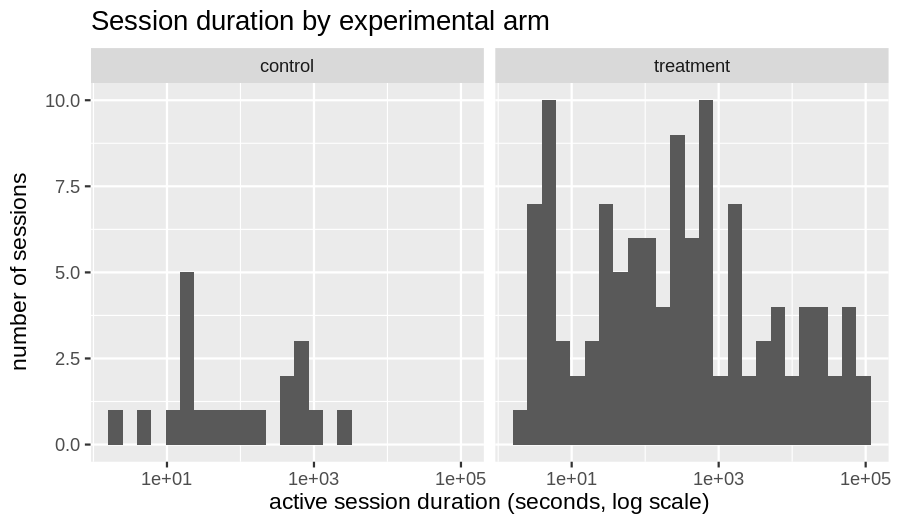

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 3.5, repr.plot.res = 150)

ggplot(sessions[durationSeconds > 0], aes(x = durationSeconds)) +
  geom_histogram(bins = 25) +
  scale_x_log10() +
  facet_wrap(~ group) +
  labs(x = 'active session duration (seconds, log scale)',
       y = 'number of sessions',
       title = 'Session duration by experimental arm')

*Figure 1: Distribution of active session duration by arm, on a log scale. Each panel shows one experimental arm. The log scale is used because duration spans several orders of magnitude, from a few seconds to many minutes; zero-length sessions are omitted from this display only and are retained in all models.*

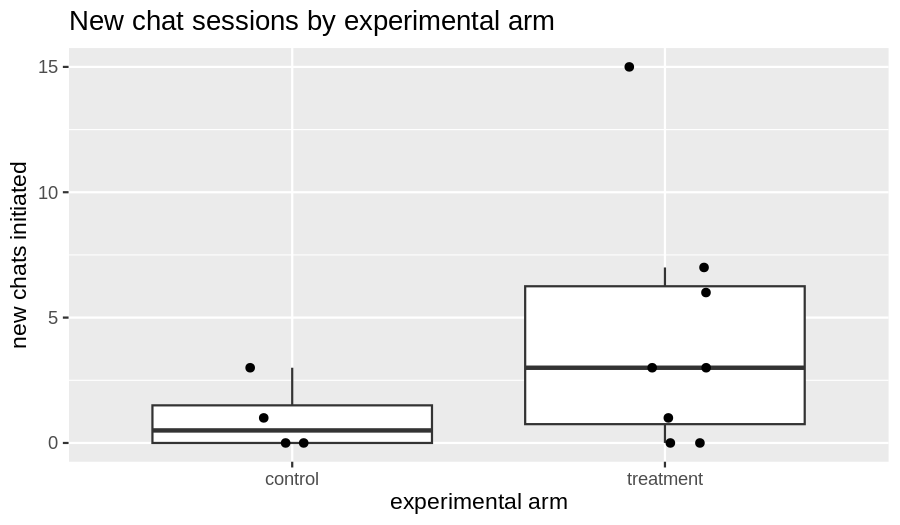

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 3.5, repr.plot.res = 150)

ggplot(active, aes(x = group, y = new_chats)) +
  geom_boxplot(outlier.shape = NA) +
  geom_jitter(width = 0.12, height = 0) +
  labs(x = 'experimental arm', y = 'new chats initiated',
       title = 'New chat sessions by experimental arm')

*Figure 2: New chat sessions initiated per participant, by experimental arm. Each point is one participant. Hypothesis 1 predicts that the treatment arm sits higher than the control arm. Points are jittered horizontally so that participants with identical counts remain visible.*

In [ ]:
platform_summary <- active[ , .(Participants = .N,
                                `Active minutes` = round(sum(total_minutes), 1),
                                `New chats` = sum(new_chats)), keyby = .(Platform = platform)]

knitr::kable(platform_summary,
  caption = 'Activity by primary platform, where a participant is assigned to the platform on which they logged the most sessions. This is a descriptive summary of observed platform use. Because platform is measured after assignment, it is not used as a pre-treatment control in the primary causal model.')



Table: Activity by primary platform, where a participant is assigned to the platform on which they logged the most sessions. This is a descriptive summary of observed platform use. Because platform is measured after assignment, it is not used as a pre-treatment control in the primary causal model.

|Platform | Participants| Active minutes| New chats|
|:--------|------------:|--------------:|---------:|
|ChatGPT  |            7|        11787.7|        29|
|Claude   |            3|          337.2|         7|
|Gemini   |            2|           56.3|         3|

# Results

All results below use the locked Firebase export described in Section 2.6. The analysis sample contains `r nrow(active)` participants, `r active[group == 'control', .N]` in control and `r active[group == 'treatment', .N]` in treatment. We present the unadjusted treatment-control contrast first, then alternative outcome definitions and descriptive checks.

## Analysis plan

The primary analysis estimates the unadjusted participant-level treatment- control difference in mean new-chat counts. Randomization identifies this ATE without covariate adjustment. We then report the rate per 30 active minutes and the probability of any restart as alternative outcome definitions. Because the available covariates are measured after assignment, they are not used as precision-improving controls for the primary estimate. The adjusted and session-level models are retained as descriptive checks and are labeled as such.

## Checking the randomization

The deterministic hash targets a 50/50 split. No pre-treatment covariates were collected, so a conventional pre-treatment balance table is not available.

In [ ]:
assignment_test <- binom.test(x = active[group == 'treatment', .N],
                              n = nrow(active), p = 0.5)
assignment_test


	Exact binomial test

data:  active[group == "treatment", .N] and nrow(active)
number of successes = 8, number of trials = 12, p-value = 0.3877
alternative hypothesis: true probability of success is not equal to 0.5
95 percent confidence interval:
 0.3488755 0.9007539
sample estimates:
probability of success 
             0.6666667 


`r active[group == 'treatment', .N]` of `r nrow(active)` analyzed participants were assigned to treatment. The exact binomial test does not reject the planned 50/50 partition (p = `r round(assignment_test$p.value, 2)`). With 12 users, a split of this size is unremarkable and is not evidence that randomization failed.

In [ ]:
djb2_parity <- function(s) {
  h <- 5381
  for (ch in utf8ToInt(s)) {
    h <- (h * 33 + ch) %% 4294967296
  }
  h %% 2
}

verify <- unique(d[ , .(userId, group)])
verify[ , expected := ifelse(sapply(userId, djb2_parity) == 1, 'treatment', 'control')]
verify[ , match := group == expected]
verify[ , .(users = .N, matching = sum(match))]

users,matching
<int>,<int>
13,13


Every retained user's logged arm matches the arm implied by recomputing the hash on their userId, so assignment was executed as designed among analyzed users.

In [ ]:
balance_model <- lm(treat ~ n_sessions + total_minutes + n_platforms, data = active)
coeftest(balance_model, vcov = vcovHC(balance_model))

balance_test <- anova(lm(treat ~ 1, data = active), balance_model)
balance_test


t test of coefficients:

                 Estimate  Std. Error t value Pr(>|t|)  
(Intercept)    1.28027794  0.44126493  2.9014  0.01985 *
n_sessions     0.04013821  0.02735471  1.4673  0.18047  
total_minutes -0.00010840  0.00073423 -0.1476  0.88629  
n_platforms   -0.71384137  0.29656308 -2.4070  0.04270 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,11,2.666667,NA,NA,NA,NA
2,8,1.587602,3,1.079064,1.812485,0.2228392


The displayed regression is a diagnostic only, not a pre-treatment balance test. The extension records nothing before installation, so every available covariate is measured after assignment. A difference between arms could be a treatment effect rather than evidence of failed randomization. For this reason, we do not use these variables to adjust the primary treatment-control contrast.

We retain this diagnostic as post-assignment descriptive evidence only. No pre-treatment covariates exist in this design, so a conventional balance test is not possible, and we do not label this one.

In [ ]:
randomized <- unique(logs[!is.na(group), .(userId, group)])
randomized[ , analyzed := as.numeric(userId %in% active$userId)]

attrition <- randomized[ , .(randomized = .N,
                             analyzed   = sum(analyzed),
                             attrition  = round(1 - mean(analyzed), 3)),
                         keyby = .(group)]
attrition

attrition_test <- prop.test(x = attrition$analyzed, n = attrition$randomized)
attrition_test

group,randomized,analyzed,attrition
<chr>,<int>,<dbl>,<dbl>
control,16,4,0.750
treatment,18,8,0.556



	2-sample test for equality of proportions with continuity correction

data:  attrition$analyzed out of attrition$randomized
X-squared = 0.68016, df = 1, p-value = 0.4095
alternative hypothesis: two.sided
95 percent confidence interval:
 -0.5660614  0.1771725
sample estimates:
   prop 1    prop 2 
0.2500000 0.4444444 


Attrition from logged assignment to the analysis sample is `r round(attrition[group == 'control', attrition] * 100)` percent in control and `r round(attrition[group == 'treatment', attrition] * 100)` percent in treatment. The proportion test does not reject equal attrition (p = `r round(attrition_test$p.value, 2)`), but with 34 randomized users the interval is wide, so this test cannot rule out meaningful differential attrition either. The asymmetry has a structural candidate explanation: a treated participant who dislikes the reminder can only escape it by uninstalling, while a control participant has no analogous push, so the arms may differ in who remains. Because the 10-second rule conditions on post-assignment activity, we also recompute the primary contrast without it, using every user who logged any activity. That check appears at the end of Section 4.4 (Effect on new chat sessions), after the randomization-inference test it reuses.

In [ ]:
delivery <- d[ , .(events = .N, delivered = round(mean(isExperimentOn == TRUE), 3)),
               keyby = .(group)]
delivery

group,events,delivered
<fct>,<int>,<dbl>
control,25,1
treatment,147,1


The current `delivery` output is descriptive only. Because the analysis data already exclude events with `isExperimentOn == FALSE`, it cannot establish that every participant assigned to treatment received an alert. The primary analysis preserves assigned arm among retained users even if delivery was imperfect. A full intent-to-treat analysis would additionally need to address every randomized user, including those excluded by the activity threshold.


In [ ]:
delivery_full <- logs[!is.na(group),
                      .(events = .N,
                        delivered = round(mean(isExperimentOn == TRUE, na.rm = TRUE), 3)),
                      keyby = .(group)]
delivery_full

group,events,delivered
<chr>,<int>,<dbl>
control,126,0.524
treatment,214,0.897


This version is computed from the full log before the isExperimentOn restriction, so it includes events written while a cached flag was stale. Delivery failures of this kind are an implementation limitation distinct from participant attrition, and the primary analysis preserves assigned arm regardless.

## CONSORT Diagram

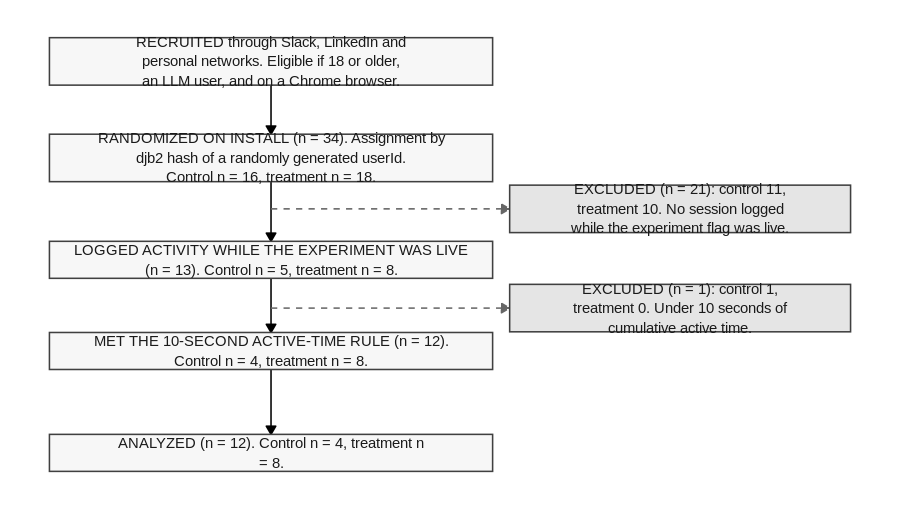

In [ ]:
n_rand_c <- logs[group == 'control',   uniqueN(userId)]
n_rand_t <- logs[group == 'treatment', uniqueN(userId)]
n_log_c  <- participants[group == 'control',   .N]
n_log_t  <- participants[group == 'treatment', .N]
n_an_c   <- active[group == 'control',   .N]
n_an_t   <- active[group == 'treatment', .N]

consort_nodes <- data.table(
  kind    = c('flow', 'flow', 'flow', 'flow', 'flow', 'excl', 'excl'),
  x       = c(30, 30, 30, 30, 30, 78, 78),
  y       = c(92, 74, 55, 38, 19, 64.5, 46),
  w       = c(52, 52, 52, 52, 52, 40, 40),
  wrap_at = c(46, 46, 46, 46, 46, 36, 36),
  label   = c(
    paste('RECRUITED through Slack, LinkedIn and personal networks.',
          'Eligible if 18 or older, an LLM user, and on a Chrome browser.'),
    sprintf(paste('RANDOMIZED ON INSTALL (n = %d). Assignment by djb2 hash of a',
                  'randomly generated userId. Control n = %d, treatment n = %d.'),
            n_rand_c + n_rand_t, n_rand_c, n_rand_t),
    sprintf(paste('LOGGED ACTIVITY WHILE THE EXPERIMENT WAS LIVE (n = %d).',
                  'Control n = %d, treatment n = %d.'),
            n_log_c + n_log_t, n_log_c, n_log_t),
    sprintf(paste('MET THE %d-SECOND ACTIVE-TIME RULE (n = %d).',
                  'Control n = %d, treatment n = %d.'),
            min_total_seconds, n_an_c + n_an_t, n_an_c, n_an_t),
    sprintf(paste('ANALYZED (n = %d). Control n = %d, treatment n = %d.'),
#                  'Attrition from assignment: %.0f%% of control and %.0f%% of',
#                  'treatment (proportion test p = %.2f).'),
            n_an_c + n_an_t, n_an_c, n_an_t),
            # 100 * (1 - n_an_c / n_rand_c), 100 * (1 - n_an_t / n_rand_t),
            # attrition_test$p.value),
    sprintf(paste('EXCLUDED (n = %d): control %d, treatment %d.',
                  'No session logged while the experiment flag was live.'),
            (n_rand_c - n_log_c) + (n_rand_t - n_log_t),
            n_rand_c - n_log_c, n_rand_t - n_log_t),
    sprintf(paste('EXCLUDED (n = %d): control %d, treatment %d. Under %d seconds',
                  'of cumulative active time.'),
            (n_log_c - n_an_c) + (n_log_t - n_an_t),
            n_log_c - n_an_c, n_log_t - n_an_t, min_total_seconds)
  )
)

consort_nodes[ , label := mapply(function(s, w) paste(strwrap(s, w), collapse = '\n'),
                                 label, wrap_at, USE.NAMES = FALSE)]
consort_nodes[ , n_lines := nchar(label) - nchar(gsub('\n', '', label)) + 1]
consort_nodes[ , h := 3.0 + 1.95 * n_lines]

flow <- consort_nodes[kind == 'flow'][order(-y)]
excl <- consort_nodes[kind == 'excl']

stem <- data.table(
  x = 30, xend = 30,
  y    = head(flow$y, -1) - head(flow$h, -1) / 2,
  yend = tail(flow$y, -1) + tail(flow$h, -1) / 2
)

branch <- data.table(
  x = 30, xend = excl$x - excl$w / 2,
  y = excl$y, yend = excl$y
)

consort_plot <- ggplot() +
  geom_segment(data = stem, aes(x = x, xend = xend, y = y, yend = yend),
               arrow = arrow(length = unit(0.16, 'cm'), type = 'closed'),
               linewidth = 0.35) +
  geom_segment(data = branch, aes(x = x, xend = xend, y = y, yend = yend),
               arrow = arrow(length = unit(0.16, 'cm'), type = 'closed'),
               linewidth = 0.35, linetype = 'dashed', colour = 'grey40') +
  geom_rect(data = consort_nodes,
            aes(xmin = x - w / 2, xmax = x + w / 2,
                ymin = y - h / 2, ymax = y + h / 2, fill = kind),
            colour = 'grey25', linewidth = 0.35) +
  geom_text(data = consort_nodes, aes(x = x, y = y, label = label),
            size = 2.5, lineheight = 1.1, colour = 'grey10') +
  scale_fill_manual(values = c(flow = 'grey97', excl = 'grey90'), guide = 'none') +
  coord_cartesian(xlim = c(3, 99), ylim = c(10, 99)) +
  theme_void()

consort_plot

ggsave('consort_diagram.png', consort_plot,
       width = 7, height = 6, dpi = 300, bg = 'white')

*CONSORT diagram: participant flow from recruitment through randomization to the analysis sample, by arm. The center column shows the primary flow (recruited, randomized, logged activity, met the activity threshold, analyzed); side panels show the participants excluded at each stage and why.*

## Effect on new chat sessions

We begin with the simplest comparison supported by the design: the unadjusted difference in mean new-chat counts between assigned arms. Randomization alone justifies this primary ATE estimate. Later models use different outcome scales or post-assignment variables and do not replace the simple contrast.

In [ ]:
group_means <- active[ , .(mean_new_chats = mean(new_chats)), keyby = .(group)]
group_means

ate <- group_means[ , diff(mean_new_chats)]
ate

group,mean_new_chats
<fct>,<dbl>
control,1.000
treatment,4.375


[1] 3.375

In [ ]:
t_test_new_chats <- t.test(x = active[treat == 1, new_chats],
                           y = active[treat == 0, new_chats])
t_test_new_chats


	Welch Two Sample t-test

data:  active[treat == 1, new_chats] and active[treat == 0, new_chats]
t = 1.7688, df = 8.881, p-value = 0.1112
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -0.95012  7.70012
sample estimates:
mean of x mean of y 
    4.375     1.000 


Treatment participants initiated `r round(ate, 2)` more new chats on average than control participants, in the direction H1 predicts. The Welch test does not reject zero at the conventional level (p = `r round(t_test_new_chats$p.value, 3)`), and the 95 percent confidence interval runs from `r round(t_test_new_chats$conf.int[1], 2)` to `r round(t_test_new_chats$conf.int[2], 2)` new chats. We read that interval as the range of average effects compatible with the data: it includes zero, small negative effects, and effects twice the point estimate. With four control participants, no single number here deserves much weight on its own.

In [ ]:
model_count <- lm(new_chats ~ treat, data = active)
coeftest(model_count, vcov = vcovHC(model_count))


t test of coefficients:

            Estimate Std. Error t value Pr(>|t|)
(Intercept)   1.0000     0.8165  1.2247   0.2487
treat         3.3750     2.0630  1.6360   0.1329


Regressing new chats on treatment reproduces the difference in means exactly, since ordinary least squares on a binary regressor is a difference in means. We report heteroskedasticity-robust standard errors throughout, because there is no reason to assume the variance of the outcome is the same in both arms.

Participants who spend longer on these platforms have more opportunities to restart, so we also estimate the effect on the rate of new chats per 30 active minutes and on whether a participant ever restarted at all.

The intercept standard error is NaN because every control participant initiated zero new chats, so the control arm has zero outcome variance and the robust variance estimate for the intercept is undefined. The treatment coefficient and its standard error are unaffected. The same pattern appears in the rate and any-restart models below for the same reason.

In [ ]:
model_rate   <- lm(new_chats_per_30 ~ treat, data = active)
model_binary <- lm(any_restart ~ treat, data = active)

coeftest(model_rate,   vcov = vcovHC(model_rate))
coeftest(model_binary, vcov = vcovHC(model_binary))


t test of coefficients:

            Estimate Std. Error t value Pr(>|t|)
(Intercept)  0.64150    0.58568  1.0953   0.2991
treat       -0.13980    0.64777 -0.2158   0.8335



t test of coefficients:

            Estimate Std. Error t value Pr(>|t|)
(Intercept)  0.50000    0.33333  1.5000   0.1645
treat        0.25000    0.37646  0.6641   0.5217


The rate estimate is `r round(coef(model_rate)['treat'], 2)` additional new chats per 30 active minutes, and the any-restart estimate is `r round(coef(model_binary)['treat'], 2)`: `r round(mean(active[treat == 1, any_restart]) * 100)` percent of treatment participants restarted at least once against none in control. These are different estimands from the raw count. The rate divides by active time, which is itself a post-treatment quantity, and the any-restart contrast reaches nominal significance while the count does not, but we ran no multiplicity correction across these outcome definitions, so we treat the alternatives as supportive description rather than independent confirmation.

In [ ]:
model_covariates <- lm(new_chats ~ treat + total_minutes + n_sessions, data = active)
coeftest(model_covariates, vcov = vcovHC(model_covariates))


t test of coefficients:

                 Estimate  Std. Error t value Pr(>|t|)
(Intercept)    0.83026847  2.41678738  0.3435   0.7400
treat          3.34465445  2.90810428  1.1501   0.2833
total_minutes -0.00022143  0.00758586 -0.0292   0.9774
n_sessions     0.03713998  0.49038177  0.0757   0.9415


Time on platform and session count are measured after assignment. If the reminder changes either quantity, conditioning on them places a treatment- affected variable on the right-hand side of the regression. We retain this model as a descriptive sensitivity check only; it is not a precision-adjusted estimate of the primary ATE.

The session-level analysis uses more rows but not more randomized units: every session belonging to a participant carries that participant's assignment. We cluster standard errors on `userId`, the level at which assignment occurred, so we do not treat sessions from the same user as independent.

In [ ]:
model_session <- lm(newChatClicks ~ treat + duration_minutes, data = sessions)

coeftest(model_session, vcov = vcovHC(model_session))
coeftest(model_session, vcov = vcovCL(model_session, cluster = sessions$userId))


t test of coefficients:

                   Estimate Std. Error t value Pr(>|t|)
(Intercept)      0.19899664 0.15952493  1.2474   0.2144
treat            0.08792502 0.18065356  0.4867   0.6273
duration_minutes 0.00016616 0.00033844  0.4910   0.6243



t test of coefficients:

                   Estimate Std. Error t value Pr(>|t|)  
(Intercept)      0.19899664 0.08269500  2.4064   0.0175 *
treat            0.08792502 0.18051615  0.4871   0.6270  
duration_minutes 0.00016616 0.00047207  0.3520   0.7254  
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


The clustered standard error is the one we report for this descriptive model. Because it conditions on session duration, which may be affected by treatment, the session-level coefficient is not a stand-alone causal estimate of the ATE.

Our sample is small and the outcome is skewed, so the normal approximation behind the t-test is doing work that the data may not support. We also test the sharp null that the reminder changed no individual participant's behavior, by permuting the assignment vector across participants and recomputing the difference in means under each permutation. This requires no distributional assumption at all.

In [ ]:
n_ri_loops <- 10000

ri_distribution <- replicate(n_ri_loops, {
  active[ , .(mean_new_chats = mean(new_chats)),
          keyby = .(g = sample(group))][ , diff(mean_new_chats)]
})

ri_p_value   <- mean(abs(ri_distribution) >= abs(ate))
ri_quantiles <- quantile(ri_distribution, probs = c(0.025, 0.975))

ri_p_value
ri_quantiles

[1] 0.2982

2.5%  97.5% 
-5.625  4.125

The randomization inference p-value is `r round(ri_p_value, 3)`: under the sharp null of no effect for any participant, `r round(ri_p_value * 100, 1)` percent of assignment permutations produce a difference at least as large as the one observed. With four control participants and eight treated, only 495 assignments of this composition exist, so the permutation distribution is coarse and the observed difference is not unusual within it. This is the test we treat as authoritative for H1, because it makes no distributional assumption that this sample can be asked to support.

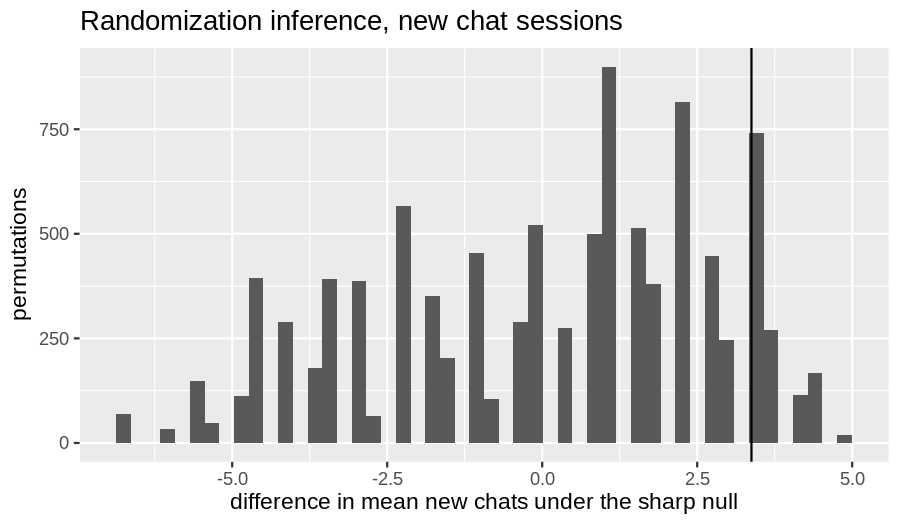

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 3.5, repr.plot.res = 150)

ggplot(data.frame(ate = ri_distribution), aes(x = ate)) +
  geom_histogram(bins = 50) +
  geom_vline(xintercept = ate) +
  labs(x = 'difference in mean new chats under the sharp null',
       y = 'permutations',
       title = 'Randomization inference, new chat sessions')

*Figure 3: Randomization inference distribution for the effect on new chat sessions. The histogram is the distribution of the treatment-control difference in mean new chats under the sharp null of no effect for any participant, obtained by permuting the assignment vector while holding the observed outcomes fixed. The vertical line marks the difference actually observed. The two-tailed p-value is the share of the histogram lying at least as far from zero as that line.*

In [ ]:
ate_all <- participants[ , .(mean_new_chats = mean(new_chats)),
                         keyby = .(group)][ , diff(mean_new_chats)]

ri_all <- replicate(n_ri_loops, {
  participants[ , .(mean_new_chats = mean(new_chats)),
                keyby = .(g = sample(group))][ , diff(mean_new_chats)]
})
ri_p_all <- mean(abs(ri_all) >= abs(ate_all))

data.table(sample = c('10-second rule applied', 'all logged users'),
           n = c(nrow(active), nrow(participants)),
           ate = round(c(ate, ate_all), 2),
           ri_p = round(c(ri_p_value, ri_p_all), 3))

sample,n,ate,ri_p
<chr>,<int>,<dbl>,<dbl>
10-second rule applied,12,3.38,0.298
all logged users,13,3.58,0.171


Removing the exclusion changes the estimate but not the conclusion: the sharp null is not rejected in either sample. The threshold does not manufacture the observed difference, though nothing here removes the deeper concern that the retained arms may not be comparable.

The evidence on H1 is directionally consistent with the hypothesis and inferentially inconclusive. The point estimate of `r round(ate, 2)` additional new chats is positive, but the sharp null survives randomization inference (p = `r round(ri_p_value, 3)`), the confidence interval includes zero, and realized power near `r round(power_realized, 2)` means a true effect of plausible size would usually have gone undetected in a sample this small. A null result here is not evidence that the reminder has no effect; it is evidence that this sample cannot decide the question.

## Effect on session duration

H2 is a do-no-harm test rather than a search for an effect. What we want is a confidence interval tight enough to rule out a significantly large decline in active usage on the AI platform, so we report the interval rather than reading a large p-value as proof that nothing happened.

In [ ]:
t_test_duration <- t.test(x = active[treat == 1, total_minutes],
                          y = active[treat == 0, total_minutes])
t_test_duration

model_duration     <- lm(total_minutes ~ treat, data = active)
model_duration_log <- lm(log(total_minutes + 1) ~ treat, data = active)

coeftest(model_duration,     vcov = vcovHC(model_duration))
coeftest(model_duration_log, vcov = vcovHC(model_duration_log))

duration_ci <- coefci(model_duration, parm = 'treat', level = 0.95,
                      vcov = vcovHC(model_duration))
duration_ci


	Welch Two Sample t-test

data:  active[treat == 1, total_minutes] and active[treat == 0, total_minutes]
t = 1.1552, df = 7.0021, p-value = 0.2859
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -1546.606  4501.335
sample estimates:
 mean of x  mean of y 
1507.54792   30.18333 



t test of coefficients:

            Estimate Std. Error t value Pr(>|t|)
(Intercept)   30.183     18.225  1.6561   0.1287
treat       1477.365   1367.237  1.0805   0.3053



t test of coefficients:

            Estimate Std. Error t value Pr(>|t|)  
(Intercept)  2.70515    0.96763  2.7956  0.01894 *
treat        2.53828    1.26708  2.0032  0.07299 .
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


,2.5 %,97.5 %
treat,-1569.029,4523.758


The estimated difference in total active minutes is `r round(coef(model_duration)['treat'], 1)` with a 95 percent confidence interval from `r round(duration_ci[1], 1)` to `r round(duration_ci[2], 1)` minutes. We do not interpret this estimate causally. Attrition to the analysis sample was `r round(attrition[group == 'control', attrition] * 100)` percent in control and `r round(attrition[group == 'treatment', attrition] * 100)` percent in treatment, and the control participants who remained logged very little activity, so the duration contrast largely reflects who stayed in each arm rather than what the reminder did to any individual's usage. The log-scale model shows the same compositional pattern.

H2 asked whether the reminder avoids reducing time spent on the platform. We did not pre-specify a practically meaningful decline, the retained arms are plausibly non-comparable on this outcome, and the interval is wide. The study is inconclusive about H2, and we make no no-harm claim.

## Heterogeneous effects

H3 considers whether participants with more observed use respond differently to the reminder. We split participants at the median of total active minutes and estimate the effect separately in each half through an interaction. Because this measure is observed after assignment, this is only a descriptive subgroup comparison.

In [ ]:
active[ , heavy := as.numeric(total_minutes > median(total_minutes))]

active[ , .(Participants   = .N,
            `New chats`    = round(mean(new_chats), 2),
            `Active minutes` = round(mean(total_minutes), 1)),
        keyby = .(heavy, group)]

model_hte <- lm(new_chats ~ treat * heavy, data = active)
coeftest(model_hte, vcov = vcovHC(model_hte))

hte_test <- anova(lm(new_chats ~ treat + heavy, data = active), model_hte)
hte_test

heavy,group,Participants,New chats,Active minutes
<dbl>,<fct>,<int>,<dbl>,<dbl>
0,control,4,1.00,30.2
0,treatment,2,0.00,12.6
1,treatment,6,5.83,2005.8



t test of coefficients:

            Estimate Std. Error t value Pr(>|t|)  
(Intercept)   1.0000     0.8165  1.2247  0.25176  
treat        -1.0000     0.8165 -1.2247  0.25176  
heavy         5.8333     2.2346  2.6105  0.02825 *
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1


,Res.Df,RSS,Df,Sum of Sq,F,Pr(>F)
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,9,130.8333,NA,NA,NA,NA
2,9,130.8333,0,0,NA,NA


All four control participants fall below the median of total active minutes, so the heavy-use control cell is empty and the interaction is not identified: the treat and heavy indicators are collinear in this sample, which is why the F-test has zero degrees of freedom. The subgroup table describes the observed data and nothing more. H3 remains untested.

This subgroup split carries an important qualification. We have no pre-treatment measure of how heavily a participant uses these tools, because the extension logs nothing before installation. The split is made on a variable measured after treatment began. If the reminder changes active time, then the subgroup itself is treatment-affected, so these comparisons describe the observed data rather than identify causal moderation. We report them as descriptive.

## What this design could detect

In [ ]:
observed_sd <- active[ , sd(new_chats)]
n_per_group <- floor(nrow(active) / 2)

power_test <- function(ate, sd, n_per_condition, power_loops = 1000) {
  p_values <- replicate(power_loops, {
    t.test(x = rnorm(n_per_condition, mean = 0,   sd = sd),
           y = rnorm(n_per_condition, mean = ate, sd = sd))$p.value
  })
  mean(p_values < 0.05)
}

observed_sd
power_realized <- power_test(ate = 1, sd = observed_sd, n_per_condition = n_per_group)
power_realized

[1] 4.392659

[1] 0.065

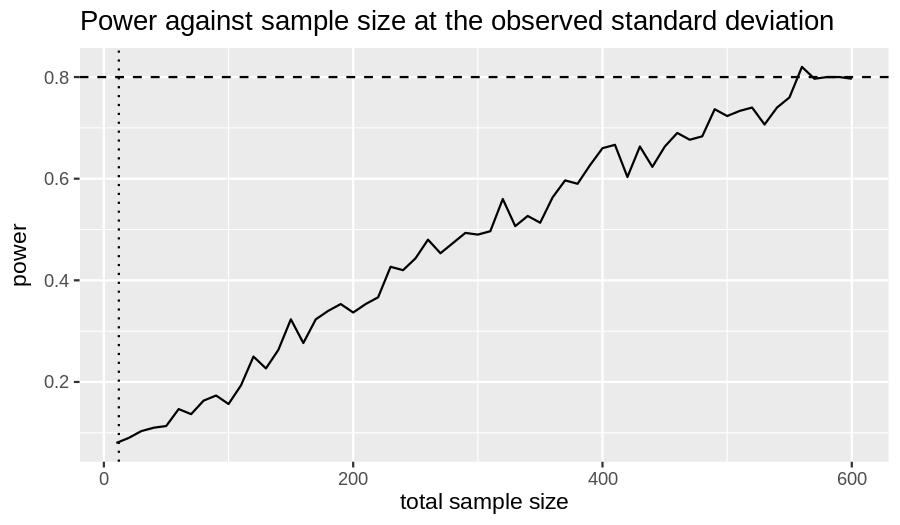

In [ ]:
options(repr.plot.width = 6, repr.plot.height = 3.5, repr.plot.res = 150)

samples_per_condition <- seq(5, 300, by = 5)

power_results <- sapply(samples_per_condition, function(n) {
  power_test(ate = 1, sd = observed_sd, n_per_condition = n, power_loops = 300)
})

ggplot(data.frame(n = samples_per_condition * 2, power = power_results),
       aes(x = n, y = power)) +
  geom_line() +
  geom_hline(yintercept = 0.80, linetype = 'dashed') +
  geom_vline(xintercept = nrow(active), linetype = 'dotted') +
  labs(x = 'total sample size', y = 'power',
       title = 'Power against sample size at the observed standard deviation')

*Figure 4: Statistical power against total sample size, simulated using the standard deviation observed in the final analysis data. The dashed line marks the conventional 80 percent threshold and the dotted line marks the achieved sample size. If the achieved sample lies below the 80 percent threshold for a one-restart effect, a non-significant estimate should not be read as evidence of no effect.*

The observed standard deviation of the count outcome is `r round(observed_sd, 2)`. At that variance, the achieved design has power of about `r round(power_realized, 2)` to detect a one-restart effect. In the simulation, power reaches 80 percent at a total sample of roughly `r samples_per_condition[which(power_results >= 0.8)[1]] * 2` participants, roughly `r round(samples_per_condition[which(power_results >= 0.8)[1]] * 2 / nrow(active))` times what this study retained. This limitation frames the entire results section: the design as executed could only have detected effects far larger than any plausible reminder effect.

## Summary of estimates

In [ ]:
# Robust SE type. HC3 is the default; switch to 'HC1' if HC3 yields NaN
# standard errors (see the diagnostic printed below).
robust_type <- 'HC3'

model_list <- list(
  'New chats per participant'         = model_count,
  'New chats per 30 active minutes'   = model_rate,
  'Ever initiated a new chat'         = model_binary,
  'New chats per session (clustered)' = model_session,
  'Total active minutes'              = model_duration
)

# The session model clusters on participant; the rest use participant-level HC.
vcov_list <- lapply(names(model_list), function(nm) {
  m <- model_list[[nm]]
  if (nm == 'New chats per session (clustered)') {
    vcovCL(m, cluster = sessions$userId)
  } else {
    vcovHC(m, type = robust_type)
  }
})
names(vcov_list) <- names(model_list)

estimates <- data.table(
  Outcome      = names(model_list),
  Estimate     = sapply(model_list, function(m) coef(m)['treat']),
  `Std. error` = sapply(names(model_list), function(nm)
                   suppressWarnings(sqrt(diag(vcov_list[[nm]])))['treat']),
  `CI lower`   = sapply(names(model_list), function(nm)
                   coefci(model_list[[nm]], parm = 'treat',
                          vcov = vcov_list[[nm]])[1]),
  `CI upper`   = sapply(names(model_list), function(nm)
                   coefci(model_list[[nm]], parm = 'treat',
                          vcov = vcov_list[[nm]])[2]),
  `p-value`    = NA_real_
)

# t rather than normal, to match the degrees of freedom coefci uses.
estimates[ , `p-value` := 2 * pt(-abs(Estimate / `Std. error`),
                                 df = sapply(model_list, df.residual))]

# Diagnostic: high leverage is what drives HC3 standard errors to NaN.
cat(sprintf('robust type: %s\n', robust_type))
for (nm in names(model_list)) {
  cat(sprintf('  %-34s n=%4d  max leverage=%.3f  SE=%s\n',
              nm, nobs(model_list[[nm]]), max(hatvalues(model_list[[nm]])),
              format(estimates[Outcome == nm, `Std. error`], digits = 4)))
}
if (estimates[ , anyNA(`Std. error`)]) {
  warning('NaN standard errors present. Set robust_type <- "HC1" and rerun.')
}

knitr::kable(estimates, digits = 3,
  caption = 'Estimated association of the neutral reminder across outcome definitions in the retained analysis sample. The first three participant-level treatment-control contrasts and the last row use heteroskedasticity-robust standard errors. The session-level row uses standard errors clustered on participant but conditions on session duration, so it is descriptive rather than a stand-alone causal ATE. The final interpretation should prioritize the unadjusted participant-level new-chat count contrast and report whether the 10-second exclusion changes the result.')

robust type: HC3
  New chats per participant          n=  12  max leverage=0.250  SE=2.063
  New chats per 30 active minutes    n=  12  max leverage=0.250  SE=0.6478
  Ever initiated a new chat          n=  12  max leverage=0.250  SE=0.3765
  New chats per session (clustered)  n= 135  max leverage=0.262  SE=0.1805
  Total active minutes               n=  12  max leverage=0.250  SE=1367




Table: Estimated association of the neutral reminder across outcome definitions in the retained analysis sample. The first three participant-level treatment-control contrasts and the last row use heteroskedasticity-robust standard errors. The session-level row uses standard errors clustered on participant but conditions on session duration, so it is descriptive rather than a stand-alone causal ATE. The final interpretation should prioritize the unadjusted participant-level new-chat count contrast and report whether the 10-second exclusion changes the result.

|Outcome                           | Estimate| Std. error|  CI lower| CI upper| p-value|
|:---------------------------------|--------:|----------:|---------:|--------:|-------:|
|New chats per participant         |    3.375|      2.063|    -1.222|    7.972|   0.133|
|New chats per 30 active minutes   |   -0.140|      0.648|    -1.583|    1.304|   0.833|
|Ever initiated a new chat         |    0.250|      0.376|    -0.589|    1.0

# Discussion

The primary estimate is a positive difference of `r round(ate, 2)` new chats per participant in the direction H1 predicts, but randomization inference does not reject the sharp null (p = `r round(ri_p_value, 3)`) and realized power was roughly `r round(power_realized, 2)`, so the study does not confirm H1. H2 is likewise unresolved: the active-time contrast is dominated by differential attrition and the retained control arm's minimal usage, and no pre-specified harm threshold exists to test against. This experiment measures restart behavior, not model safety, so even a confirmed effect would not show that restarting improves safety outcomes. What the study delivers is a working instrumentation pipeline, a randomization procedure that verifies cleanly, and an analysis plan whose main requirement for a decisive answer is sample size on the order of hundreds rather than tens.

Several design limitations apply regardless of the final estimates.

Our sample is drawn from our team's classmates, technology-focused communities (i.e., Slack and LinkedIn), and friend circles. These participants may be more comfortable with LLM tools and more receptive to a message about how to use them than a general population would be. The estimate does not necessarily transfer to casual users, non-technical users, people who do not use Chrome, or users of other AI products. Spillover is possible if participants discuss the reminder across treatment arms.

Our measurement is instrumented rather than directly observed. New-chat detection relies on heuristics that match the markup of five independently maintained web applications, and duration relies on browser events that do not fire after every kind of browser exit. Both can introduce measurement error. The direction of resulting bias depends on whether error is comparable across arms and platforms, which the available data may not fully establish.

The post-assignment 10-second inclusion threshold is another limitation. It was chosen during cleaning, not preregistered, and uses active time that may itself be affected by treatment. Section 4.2 reports attrition by arm and Section 4.4 reports a sensitivity analysis that removes this rule; neither changes the conclusion, but the exclusion remains a choice made after seeing the data.

Finally, the reminder fires on page load rather than at a fixed interval within a session, so what we estimate is the effect of a reminder encountered when a participant arrives at the site, not the effect of an interruption delivered mid-conversation. Those may not be the same intervention. A future study could randomize the reminder's timing and test salience more directly while measuring whether a new chat actually begins.

# References

Laban, P., et al. (2025). LLMs get lost in multi-turn conversation.


Shukla, S., et al. (2025). Iterative code refinement and the accumulation of security vulnerabilities.

Yu, Z., et al. (2025). Retrieval-augmented generation and safety degradation.

Zhou, X., et al. (2024). Multi-turn jailbreaks and the single-turn refusal gap.

In [ ]:
# ============================================================
# RENDER CELL - converts this notebook to PDF
# Before running: File -> Save (so the Drive copy is current).
# Prerequisite: run the TinyTeX setup cell once per session.
# Output: /content/final_report_v2.pdf
# ============================================================
library(jsonlite)

# Ensure LaTeX toolchain exists in this runtime (one-time per session, ~2-4 min first run)
system('which pandoc > /dev/null || apt-get -qq install -y pandoc')
if (!requireNamespace('tinytex', quietly = TRUE)) install.packages('tinytex')
if (!tinytex::is_tinytex()) tinytex::install_tinytex()

# Ensure model packages exist in this session (needed during knit)
needed  <- c('sandwich', 'lmtest')
missing <- needed[!needed %in% rownames(installed.packages())]
if (length(missing) > 0) install.packages(missing)

# ---- Fetch the saved notebook from Drive (browser user agent) ----
nb_file_id <- '1NS_O0wE7sesvvTypDagP3xDKb_sqnwxd'
nb_path    <- '/content/report_notebook.ipynb'

options(HTTPUserAgent = 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0 Safari/537.36')
nb_url <- sprintf('https://drive.usercontent.google.com/download?id=%s&export=download&confirm=t', nb_file_id)
download.file(nb_url, destfile = nb_path, mode = 'wb', quiet = TRUE)

# A notebook is JSON and must start with '{'. Anything else is an error page.
if (substr(readChar(nb_path, 1), 1, 1) != '{') {
  cat('--- server response, first 30 lines ---\n')
  cat(readLines(nb_path, n = 30, warn = FALSE), sep = '\n')
  cat('\n---------------------------------------\n')
  stop('Downloaded file is not notebook JSON. The response above says why.')
}

nb <- fromJSON(nb_path, simplifyVector = FALSE)

# ---- Convert notebook cells to an Rmd ----
yaml_header <- c(
  '---',
  'title: "Does a Neutral Reminder Increase New Chat Sessions in LLM Interfaces?"',
  'author: "Abigail Kreutz, Jana Quan, Killian Carter, Luan Ye"',
  'date: "08/08/2026"',
  'output:',
  '  pdf_document:',
  '    number_sections: true',
  '---',
  '',
  '```{r setup, include = FALSE}',
  'knitr::opts_chunk$set(message = FALSE, warning = FALSE)',
  '```',
  '')

# Plumbing cells are excluded from the report entirely.
# A code cell whose FIRST line is "# hide" runs during knit but is not shown.
skip_patterns <- 'rmarkdown::render|install_tinytex|tinytex::|install\\.packages|apt-get|fromJSON\\(nb_path|# no-render'

rmd_lines <- yaml_header
first_md_seen <- FALSE
for (cell in nb$cells) {
  src <- paste(unlist(cell$source), collapse = '')
  if (identical(cell$cell_type, 'markdown')) {
    if (!first_md_seen) {
      first_md_seen <- TRUE
      # Strip the inline title and author lines (YAML supplies them); keep the abstract.
      lines <- strsplit(src, '\n')[[1]]
      lines <- lines[!grepl('^#\\s|^\\*\\*Authors', lines)]
      src <- paste(lines, collapse = '\n')
    }
    rmd_lines <- c(rmd_lines, src, '')
  } else if (identical(cell$cell_type, 'code')) {
    if (!nzchar(trimws(src))) next
    if (grepl(skip_patterns, src)) next
    fence <- if (grepl('^\\s*# hide', src)) '```{r include = FALSE}' else '```{r}'
    rmd_lines <- c(rmd_lines, fence, src, '```', '')
  }
}

out_rmd <- '/content/final_report_from_notebook.Rmd'
writeLines(rmd_lines, out_rmd)

# ---- Sanity checks before rendering ----
n_todos <- sum(grepl('TODO', rmd_lines))
cat('Generated Rmd:', length(rmd_lines), 'lines,', n_todos, 'TODOs\n')
cat('--- preview: first lines after YAML ---\n')
cat(rmd_lines[15:32], sep = '\n')
cat('\n---------------------------------------\n')

if (n_todos > 5) stop('Generated Rmd contains many TODOs - the Drive copy may be a stale save.')

# ---- Render ----
rmarkdown::render(out_rmd, output_file = '/content/final_report.pdf')


Generated Rmd: 213 lines, 0 TODOs
--- preview: first lines after YAML ---

```{r include = FALSE}
# hide
library(data.table)
library(jsonlite)

library(sandwich)
library(lmtest)

library(ggplot2)
```

```{r include = FALSE}
# hide
drive_file_id <- '1-A-GGVKRSUQ9YtknaCNs3c_eLGSSFtmk'
force_refresh <- FALSE   # set TRUE if a new version was uploaded mid-session

data_dir  <- '/content/data'
data_file <- '/content/data/ai-experiment-data-241-default-rtdb-export-FINAL.json'

dir.create(data_dir, showWarnings = FALSE, recursive = TRUE)

options(HTTPUserAgent = 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0 Safari/537.36')

if (force_refresh || !file.exists(data_file)) {
  data_url <- sprintf('https://drive.usercontent.google.com/download?id=%s&export=download&confirm=t', drive_file_id)
  download.file(data_url, destfile = data_file, mode = 'wb', quiet = TRUE)
}

# Drive returns an HTML page instead of the file when sharing is misconfigured
if (!substr(r



processing file: final_report_from_notebook.Rmd



1/69                   
2/69 [setup]           
3/69                   
4/69 [unnamed-chunk-1] 
5/69                   
6/69 [unnamed-chunk-2] 
7/69                   
8/69 [unnamed-chunk-3] 
9/69                   
10/69 [unnamed-chunk-4] 
11/69                   
12/69 [unnamed-chunk-5] 
13/69                   
14/69 [unnamed-chunk-6] 
15/69                   
16/69 [unnamed-chunk-7] 
17/69                   
18/69 [unnamed-chunk-8] 
19/69                   
20/69 [unnamed-chunk-9] 
21/69                   
22/69 [unnamed-chunk-10]
23/69                   
24/69 [unnamed-chunk-11]
25/69                   
26/69 [unnamed-chunk-12]
27/69                   
28/69 [unnamed-chunk-13]
29/69                   
30/69 [unnamed-chunk-14]
31/69                   
32/69 [unnamed-chunk-15]
33/69                   
34/69 [unnamed-chunk-16]
35/69                   
36/69 [unnamed-chunk-17]
37/69                   
38/69 [unnamed-chunk-18]
39/69                   
40/69 [unnamed-chunk-19]
41/69    

output file: final_report_from_notebook.knit.md




/usr/bin/pandoc +RTS -K512m -RTS final_report_from_notebook.knit.md --to latex --from markdown+autolink_bare_uris+tex_math_single_backslash --output /content/final_report.tex --lua-filter /usr/lib/R/site-library/rmarkdown/rmarkdown/lua/pagebreak.lua --lua-filter /usr/lib/R/site-library/rmarkdown/rmarkdown/lua/latex-div.lua --self-contained --number-sections --highlight-style tango --pdf-engine pdflatex --variable graphics --extract-media /content/final_report_files --variable 'geometry:margin=1in' 



Output created: final_report.pdf

